In [1]:
from ultralytics import YOLO
import os
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%matplotlib inline

In [3]:
# Carregar o modelo treinado
model = YOLO(r'C:\Users\eric.santoss\Documents\corrosion_detection_mlops\src\model_train\runs\detect\custom_yolo_model_yolo26n-3\weights\best.pt')

In [4]:
model.info()

YOLO26n summary: 260 layers, 2,504,190 parameters, 0 gradients, 5.9 GFLOPs


(260, 2504190, 0, 5.8921984)

In [5]:
# Avaliar especificamente no conjunto de TESTE
metrics = model.val(data=r"C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\data.yaml", split='test')

Ultralytics 8.4.139  Python-3.11.5 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 389.0254.0 MB/s, size: 189.8 KB)
val: Scanning C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\labels\test.cache... 106 images, 6 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 106/106  0.0s
val: C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\000593_jpg.rf.3KHznpvEtxsnA1zYVrIv.jpg: 1 duplicate labels removed
val: C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\CM3_jpg.rf.4Rx4egBvOVd07CQDEY2a.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0112205]
val: C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\craiyon_082045_rust_on_a_metal_surface_png_png.rf.4ZIntPN7DYKKAVGbegdl.png: ignoring corrupt image/label: non-normalized or out

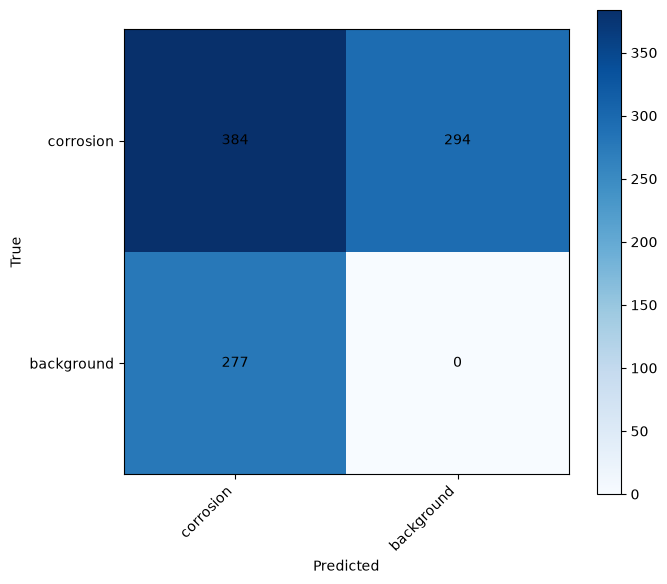

In [6]:
cm = metrics.confusion_matrix.matrix

labels = ["corrosion",
          "background"]

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            int(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [10]:
import glob
import imageio
import cv2

test_dir = r'C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test'
pred_dir = os.path.join(test_dir, "predicted_frames")
os.makedirs(pred_dir, exist_ok=True)

image_paths = sorted(glob.glob(os.path.join(test_dir, "*.jpg")))

frames = []
target_shape = None

for img_path in image_paths:
    try:
        results = model.predict(source=img_path, imgsz=640, conf=0.25, max_det=100, verbose=False)
    except Exception as e:
        print(f'Predict failed for {os.path.basename(img_path)}: {e}')
        continue

    annotated = results[0].plot()
    if annotated is None:
        continue

    # Normalize channels to RGB uint8
    if annotated.ndim == 2:
        annotated = cv2.cvtColor(annotated, cv2.COLOR_GRAY2RGB)
    elif annotated.ndim == 3:
        ch = annotated.shape[2]
        if ch == 4:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGRA2RGB)
        elif ch == 3:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        else:
            continue
    else:
        continue

    annotated = annotated.astype('uint8')

    # Ensure consistent shape for all frames (resize to first frame shape)
    if target_shape is None:
        target_shape = annotated.shape
    if annotated.shape != target_shape:
        annotated = cv2.resize(annotated, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_AREA)

    # Save annotated frame to folder
    base = os.path.splitext(os.path.basename(img_path))[0]
    save_path = os.path.join(pred_dir, f"{base}_pred.png")
    imageio.imwrite(save_path, annotated)
    frames.append(annotated)
    print(f'Gerado e salvo frame para: {os.path.basename(img_path)} -> {save_path}')

if frames:
    print(f'Todos os frames salvos em: {pred_dir}')
else:
    print('Nenhuma imagem processada para salvar.')

Gerado e salvo frame para: 000145_jpg.rf.3Ciyvr93EegFY87t8VZK.jpg -> C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\predicted_frames\000145_jpg.rf.3Ciyvr93EegFY87t8VZK_pred.png
Gerado e salvo frame para: 000145_jpg.rf.4McDI8VOgu3gDu4DQfPY.jpg -> C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\predicted_frames\000145_jpg.rf.4McDI8VOgu3gDu4DQfPY_pred.png
Gerado e salvo frame para: 000145_jpg.rf.TD2reGDxsvfCcVgRoiBO.jpg -> C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\predicted_frames\000145_jpg.rf.TD2reGDxsvfCcVgRoiBO_pred.png
Gerado e salvo frame para: 000185_jpg.rf.55IoTmPKoMkY0kLiOjsI.jpg -> C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\predicted_frames\000185_jpg.rf.55IoTmPKoMkY0kLiOjsI_pred.png
Gerado e salvo frame para: 000351_jpg.rf.tNIazAlwRtbB8Y5ZdgpS.jpg -> C:\Users\eric.santoss\Documents\corrosion_detection_mlops\data\images\test\predicted_frames\000351_jpg.rf.tNIaz